# Exploratory Data Analysis

In [20]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import cv2
from tqdm import tqdm

## 1. Dataset loading

In [2]:
def load_dataset(origin_path='../data/origin/'):
    base_path = Path(origin_path)
    data = []
    for label_dir in [x for x in base_path.iterdir() if x.is_dir()]:
        label = label_dir.name
        
        for video_file in [x for x in label_dir.iterdir() if x.is_file()]:
            data.append({
                'id': video_file.stem,
                'video_path': str(video_file),
                'label': label
            })

    return pd.DataFrame(data, columns=['id', 'video_path', 'label'])

In [16]:
dataframe = load_dataset()
print(dataframe.head())

               id                                    video_path       label
0  brush_hair_001  ..\data\origin\brush_hair\brush_hair_001.mp4  brush_hair
1  brush_hair_002  ..\data\origin\brush_hair\brush_hair_002.mp4  brush_hair
2  brush_hair_003  ..\data\origin\brush_hair\brush_hair_003.mp4  brush_hair
3  brush_hair_004  ..\data\origin\brush_hair\brush_hair_004.mp4  brush_hair
4  brush_hair_005  ..\data\origin\brush_hair\brush_hair_005.mp4  brush_hair


## 2. General Exploration

### 2.1. Label distribution

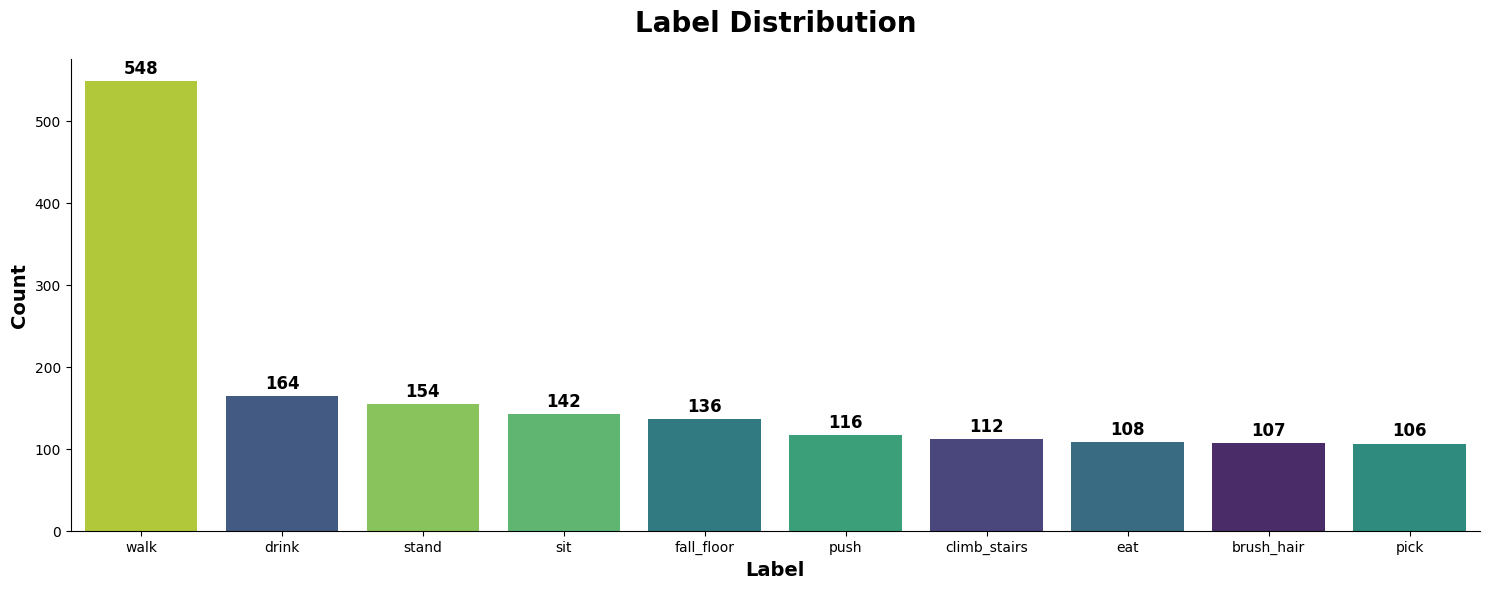

In [17]:
plt.figure(figsize=(15, 6))

ax = sns.countplot(
    data=dataframe, 
    x='label', 
    hue='label',
    legend=False,
    order=dataframe['label'].value_counts().index,
    palette='viridis'
)

plt.title('Label Distribution', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Label', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3, fontweight='bold')

plt.xticks(
    # rotation=45, 
    # ha='right', 
    fontsize=10
)
sns.despine()
plt.tight_layout()
plt.show()

> **Insight**: Severe class imbalance at a `548 : 106` ratio forces gradient descent to be dominated by the majority class, resulting in biased convergence. Accuracy becomes a misleading metric due to the baseline trap, necessitating Macro-F1 Score optimization for class equity. \
> **Action**: Training mandates Stratified Sampling coupled with Weighted Cross-Entropy Loss to rebalance gradient contributions for rare fine-grained motion features.

### 2.2. Duration distribution

In [21]:
def extract_video_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input: DataFrame chứa cột 'video_path'
    Output: DataFrame với các cột ['duration', 'number_of_frames', 'fps']
    """
    metadata_list = []
    for path in tqdm(df['video_path'], desc="Extracting Metadata", unit="video"):
        cap = cv2.VideoCapture(str(path))
        
        if not cap.isOpened():
            metadata_list.append({'duration': np.nan, 'number_of_frames': np.nan, 'fps': np.nan})
            continue

        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = frame_count / fps if fps > 0 else 0
        
        metadata_list.append({
            'duration': round(duration, 4),
            'number_of_frames': frame_count,
            'fps': round(fps, 2)
        })
        
        cap.release()

    return pd.DataFrame(metadata_list)

In [22]:
metadata = extract_video_metadata(dataframe)

Extracting Metadata: 100%|██████████| 1693/1693 [00:29<00:00, 57.62video/s]


In [37]:
print(metadata.head())

   duration  number_of_frames   fps
0   13.6333               409  30.0
1   13.1667               395  30.0
2   10.7667               323  30.0
3    8.2000               246  30.0
4    5.3000               159  30.0


#### 2.2.1. General Duration

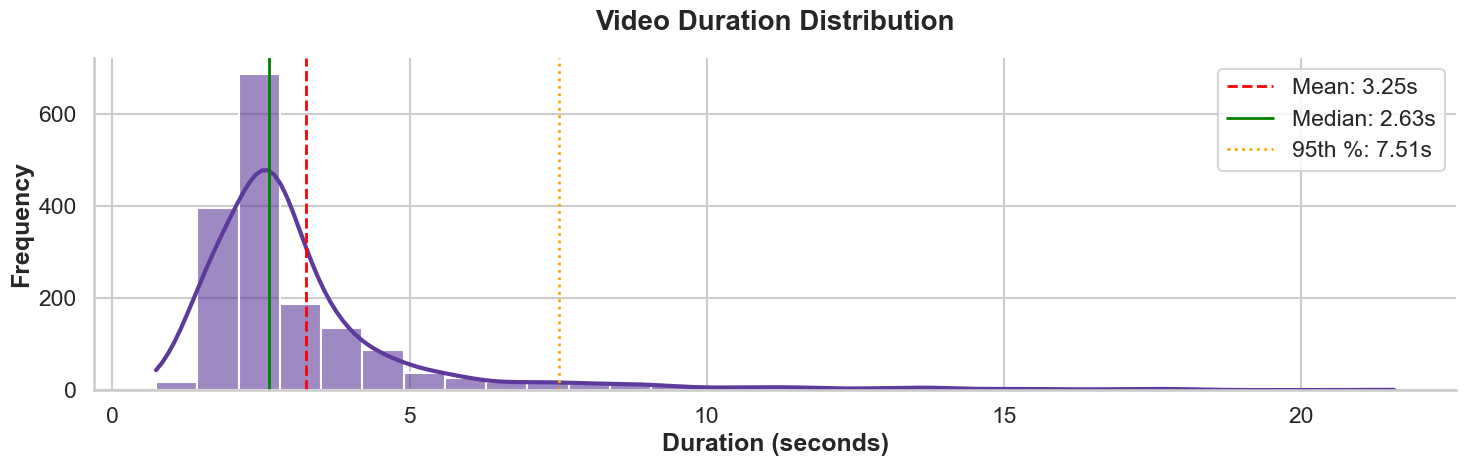

In [24]:
plt.figure(figsize=(15, 5))
sns.set_theme(style="whitegrid", context="talk")

sns.histplot(
    data=metadata, 
    x='duration', 
    kde=True, 
    bins=30, 
    color='#5D3A9B', 
    alpha=0.6,
    line_kws={'linewidth': 3}
)

mean_val = metadata['duration'].mean()
median_val = metadata['duration'].median()
p95_val = metadata['duration'].quantile(0.95)

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}s')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}s')
plt.axvline(p95_val, color='orange', linestyle=':', linewidth=2, label=f'95th %: {p95_val:.2f}s')

plt.title('Video Duration Distribution', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Duration (seconds)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

The temporal distribution is heavily right-skewed with a mean duration of 3.25 seconds and a median of 2.63 seconds. The 95th percentile threshold sits at 7.51 seconds. \
-> Indicating that a fixed sequence length of 8 seconds will capture the majority of data variance. This padding strategy optimizes computational efficiency by covering 95% of samples without excessive zero-padding. The long-tail distribution suggests the presence of unclipped raw footage that requires further preprocessing.

#### 2.2.2. Duration per class

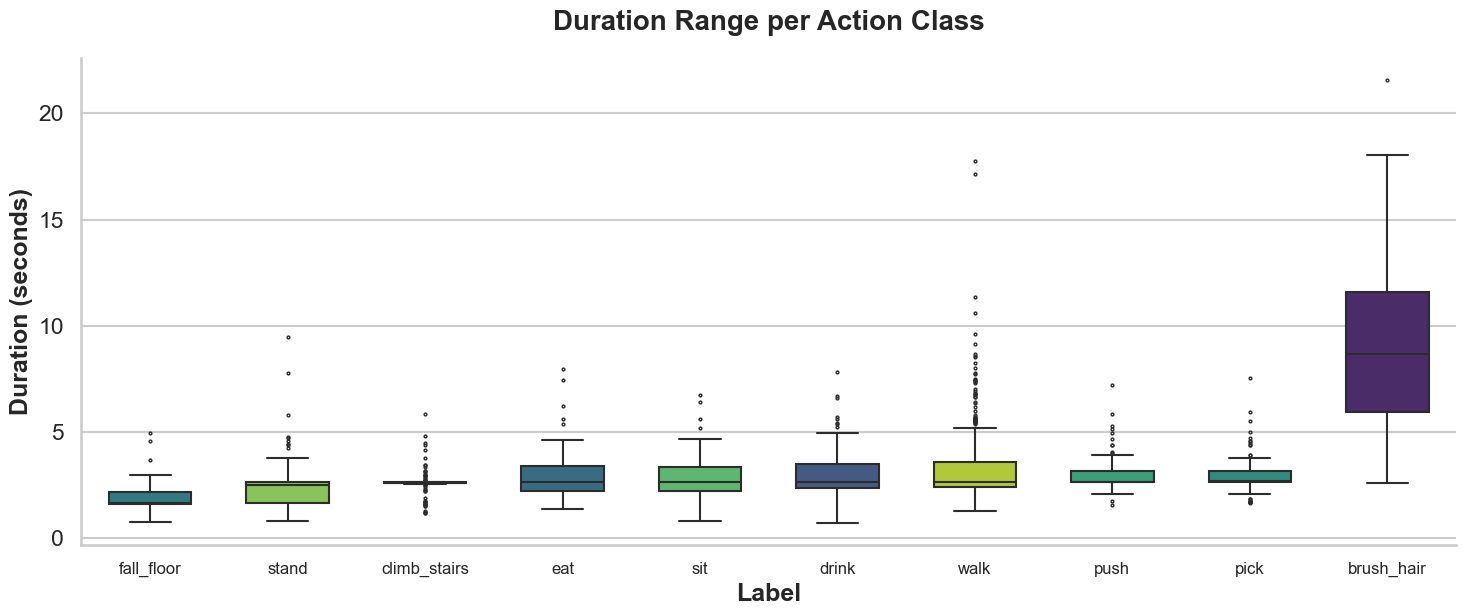

In [36]:
df = pd.concat([dataframe, metadata], axis=1)

plt.figure(figsize=(15, 6.5))
sns.set_theme(style="whitegrid", context="talk")

sorted_idx = df.groupby('label')['duration'].median().sort_values().index

sns.boxplot(
    data=df,
    x='label',
    y='duration',
    hue='label',
    legend=False,
    order=sorted_idx,
    palette='viridis',
    width=0.6,
    linewidth=1.5,
    flierprops={
        "marker": "o", 
        "markersize": 2, 
        # "markeredgecolor": "red", 
        "label": "Outliers"
    }
)

plt.title('Duration Range per Action Class', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Label', fontweight='bold')
plt.ylabel('Duration (seconds)', fontweight='bold')
plt.xticks(
    # rotation=45, 
    # ha='right', 
    fontsize=12
)
sns.despine()

plt.tight_layout()
plt.show()

**Insight**: The 'brush_hair' class exhibits a distinct temporal anomaly with a significantly higher median and interquartile range compared to the uniform short-duration profile of other categories. The 'walk' class contains a high density of extreme upper-bound outliers that deviate severely from the standard action length distribution.

**Action**: Implement a sliding window sampling strategy for 'brush_hair' to capture long-range temporal dependencies without inflating the global sequence length. Apply a strict 95th-percentile duration threshold to trim the non-representative long-tail segments in the 'walk' class to reduce model noise.

### 2.3. FPS

=== FPS CLASSIFICATION REPORT ===
fps
30.0    1693
Name: count, dtype: int64

Total videos: 1693


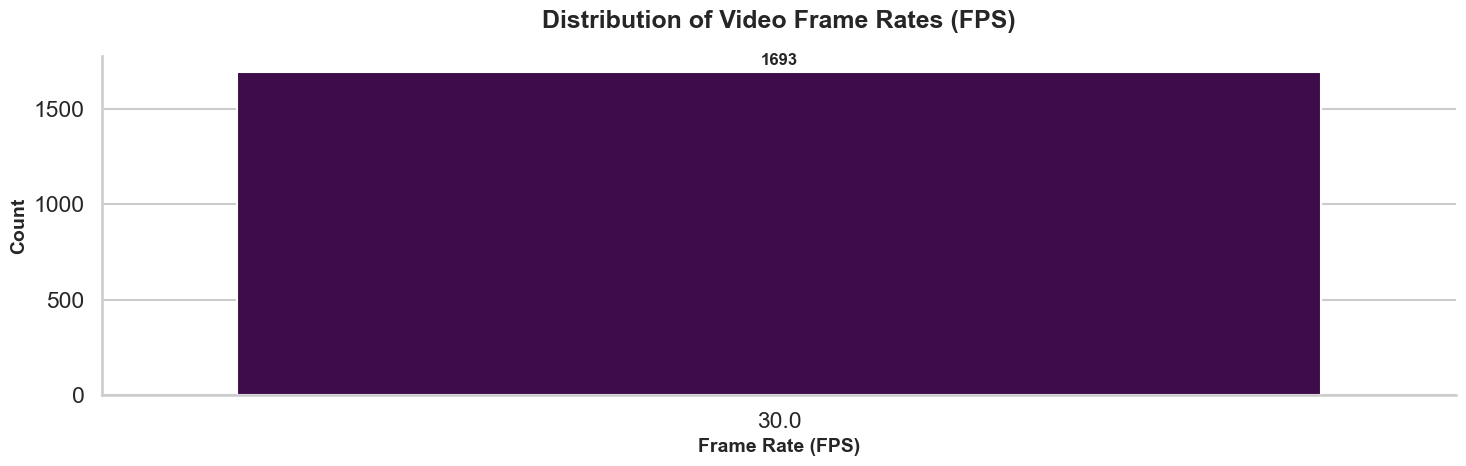

In [39]:
fps_counts = df['fps'].value_counts().sort_index()
    
print("=== FPS CLASSIFICATION REPORT ===")
print(fps_counts)
print("\nTotal videos:", len(df))
    
# --- Draw graph ---
plt.figure(figsize=(15, 5))
sns.set_theme(style="whitegrid", context="talk")
    
ax = sns.countplot(
    data=df, 
    x='fps', 
    order=df['fps'].value_counts().index,
    palette='viridis',
    hue='fps',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3, fontweight='bold')
        
plt.title('Distribution of Video Frame Rates (FPS)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Frame Rate (FPS)', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')
    
sns.despine()
plt.tight_layout()
plt.show()

The dataset exhibits absolute temporal uniformity with 100% of video samples recorded at a consistent 30 FPS. This homogeneity eliminates the computational overhead of frame resampling during the data preprocessing pipeline. The fixed temporal resolution guarantees that the model learns motion dynamics at a constant speed scale without artifacts from variable frame rates.

### 2.4. Aspect ratio

In [45]:
def visualize_aspect_ratio(df):
    """
    Input: DataFrame có cột ['label', 'aspect_ratio']
    """
    data = df.copy()
    data['aspect_ratio_rounded'] = data['aspect_ratio'].round(2)
    
    plt.figure(figsize=(16, 10))
    sns.set_theme(style="whitegrid", context="talk")
    
    # --- Common Aspect Ratios (Bar Chart) ---
    plt.subplot(2, 1, 1)
    ratio_counts = data['aspect_ratio_rounded'].value_counts().sort_index()
    
    ax1 = sns.countplot(
        data=data, 
        x='aspect_ratio_rounded', 
        hue='aspect_ratio_rounded',
        palette='magma', 
        legend=False
    )
    for container in ax1.containers:
        ax1.bar_label(container, fontsize=12, padding=3, fontweight='bold')
        
    plt.title('Distribution of Video Aspect Ratios (Global)', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('Aspect Ratio (Width/Height)', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    
    
    # --- Aspect Ratio by Class ---
    plt.subplot(2, 1, 2)
    
    sns.stripplot(
        data=data,
        x='label',
        y='aspect_ratio',
        hue='label',
        palette='viridis',
        jitter=0.2,
        size=6,
        alpha=0.7,
        legend=False
    )
    
    plt.axhline(y=1.33, color='gray', linestyle='--', alpha=0.5, label='4:3 (1.33)')
    plt.axhline(y=1.78, color='gray', linestyle='--', alpha=0.5, label='16:9 (1.78)')
    
    plt.title('Aspect Ratio Consistency by Class', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('Action Label', fontweight='bold')
    plt.ylabel('Aspect Ratio', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper right', frameon=True)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

In [43]:
def calculate_aspect_ratio(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Input: DataFrame chứa 'id', 'video_path', 'label'
    Output: DataFrame bổ sung ['width', 'height', 'aspect_ratio']
    """
    stats = []

    for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Analyzing Resolution"):
        path = str(row['video_path'])
        cap = cv2.VideoCapture(path)
        
        if not cap.isOpened():
            stats.append({'id': row['id'], 'width': np.nan, 'height': np.nan, 'aspect_ratio': np.nan})
            continue

        width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
        height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
        
        ratio = width / height if height > 0 else 0
        
        stats.append({
            'id': row['id'],
            'label': row['label'],
            'width': int(width),
            'height': int(height),
            'aspect_ratio': round(ratio, 2)
        })
        
        cap.release()

    return pd.DataFrame(stats)

In [44]:
resolution_df = calculate_aspect_ratio(df)

Analyzing Resolution: 100%|██████████| 1693/1693 [00:23<00:00, 72.15it/s]


In [47]:
print(resolution_df.head())

               id       label  width  height  aspect_ratio
0  brush_hair_001  brush_hair    320     240          1.33
1  brush_hair_002  brush_hair    320     240          1.33
2  brush_hair_003  brush_hair    320     240          1.33
3  brush_hair_004  brush_hair    416     240          1.73
4  brush_hair_005  brush_hair    416     240          1.73


#### 2.4.1. Width and height

In [63]:
def print_spatial_statistics(df):
    cols = ['width', 'height']
    
    print("=" * 50)
    print("SPATIAL RESOLUTION STATISTICS REPORT")
    print("=" * 50)
    
    for col in cols:
        desc = df[col].describe()
        Q1 = desc['25%']
        Q3 = desc['75%']
        IQR = Q3 - Q1
        median = df[col].median()
        minimum = df[col].min()
        maximum = df[col].max()
        
        print(f"► COLUMN: {col.upper()} (pixels)")
        print(f"  • Min    : {int(minimum)}")
        print(f"  • Q1 (25%): {int(Q1)}")
        print(f"  • Median : {int(median)}")
        print(f"  • Q3 (75%): {int(Q3)}")
        print(f"  • Max    : {int(maximum)}")
        print(f"  • IQR    : {IQR:.2f}")

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"  • Outliers: {len(outliers)} videos (outside [{lower_bound:.1f}, {upper_bound:.1f}])")
        print("-" * 50)

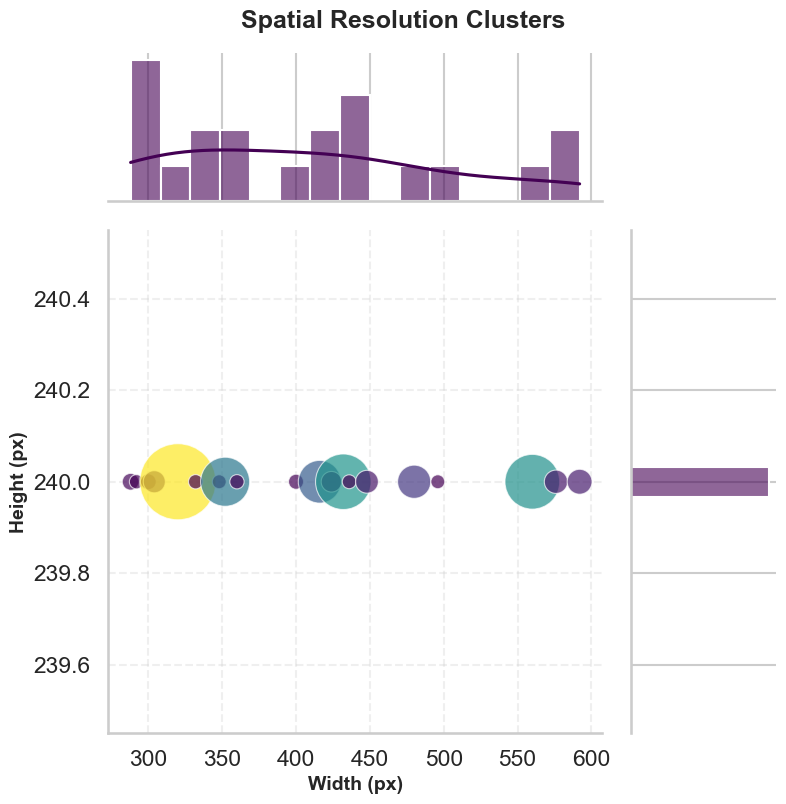

SPATIAL RESOLUTION STATISTICS REPORT
► COLUMN: WIDTH (pixels)
  • Min    : 288
  • Q1 (25%): 320
  • Median : 416
  • Q3 (75%): 480
  • Max    : 592
  • IQR    : 160.00
  • Outliers: 0 videos (outside [80.0, 720.0])
--------------------------------------------------
► COLUMN: HEIGHT (pixels)
  • Min    : 240
  • Q1 (25%): 240
  • Median : 240
  • Q3 (75%): 240
  • Max    : 240
  • IQR    : 0.00
  • Outliers: 0 videos (outside [240.0, 240.0])
--------------------------------------------------


In [64]:
plot_data = resolution_df.groupby(['width', 'height']).size().reset_index(name='count')

g = sns.JointGrid(data=plot_data, x="width", y="height", height=8, ratio=3)

sns.scatterplot(
    data=plot_data,
    x="width", y="height",
    size="count",
    hue="count",
    sizes=(100, 3000),
    palette="viridis",
    legend=False,
    alpha=0.7,
    ax=g.ax_joint
)
g.plot_marginals(sns.histplot, bins=15, color="#440154", alpha=0.6, kde=True)

g.set_axis_labels("Width (px)", "Height (px)", fontsize=14, fontweight='bold')
g.fig.suptitle("Spatial Resolution Clusters", y=1.02, fontsize=18, fontweight='bold')
g.ax_joint.grid(True, linestyle='--', alpha=0.3)

plt.show()
print_spatial_statistics(resolution_df)

**Insight**:
- The dataset demonstrates absolute vertical homogeneity with a fixed height of 240 pixels across all video samples.
- The horizontal aspect ranges widely.